# Networks Analysis

In [1]:
import pypsa
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import os

### Choose the networks to analyse

In [2]:
capacity_scenarios = ["germany_scenario1", "germany_scenario2"]

In [5]:
home = "/home/lucakristin/Desktop/my_pypsa"
cluster = "450"
folder = "germany_base-ext_"

### Create folder and paths

In [6]:
# Create analysis output directory and logging file
analysis_dir = f"{home}/pypsa-eur/analysis/{folder}"
os.makedirs(analysis_dir, exist_ok=True)
log_file = os.path.join(analysis_dir, "summary.txt")

# Initialize/clear the log file with header
with open(log_file, "w") as _f:
    _f.write(f"Networks comparison summary\n")

def log_print(*args, sep=' ', end='\n', also_print=True):
    """Helper to print and append to the summary log"""
    s = sep.join(str(a) for a in args) + end
    if also_print:
        print(*args, sep=sep, end=end)
    with open(log_file, 'a') as _f:
        _f.write(s)

def save_fig(fig, name, dpi=150):
    """Helper to save a matplotlib figure into the analysis folder"""
    fname = os.path.join(analysis_dir, name)
    fig.savefig(fname, bbox_inches='tight', dpi=dpi)
    log_print(f"Saved figure: {fname}")

### Set paths

In [7]:
# Paths to the three networks
network_paths = {
    "windy": f"{home}/pypsa-eur/results/{folder}windy/networks/base_s_{cluster}_elec_.nc",
    "notwindy": f"{home}/pypsa-eur/results/{folder}notwindy/networks/base_s_{cluster}_elec_.nc",
    "windvariability": f"{home}/pypsa-eur/results/{folder}windvariability/networks/base_s_{cluster}_elec_.nc"
}

# Load the networks
networks = {name: pypsa.Network(path) for name, path in network_paths.items()}
n1 = networks["windy"]
n2 = networks["notwindy"]
n3 = networks["windvariability"]

n1.name = "Windy"
n2.name = "Not Windy"
n3.name = "Wind Variability"

INFO:pypsa.network.io:New version 1.2.1 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.1 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.1 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks


## Check

### Installed capacities 

In [8]:
component_specs = [("generators", "p_nom"), ("storage_units", "p_nom"), ("links", "p_nom")]

for network_name, network in networks.items():
    carrier_capacity = pd.Series(dtype=float)

    for component_name, capacity_column in component_specs:
        component = getattr(network, component_name, None)
        if component is None or component.empty or "carrier" not in component.columns or capacity_column not in component.columns:
            continue
        carrier_capacity = carrier_capacity.add(component.groupby("carrier")[capacity_column].sum(), fill_value=0)

    carrier_capacity = carrier_capacity.sort_values(ascending=False)
    print(f"\n{network.name} installed capacity by carrier [MW]")
    if carrier_capacity.empty:
        print("  No carrier capacity found.")
    else:
        print(carrier_capacity.to_string(float_format=lambda value: f"{value:.2f}"))


Windy installed capacity by carrier [MW]
carrier
load                      inf
solar                86408.00
onwind               73332.07
CCGT                 30783.13
coal                 20351.94
lignite              19457.03
offwind-ac           11163.74
biomass               8020.00
PHS                   7361.72
OCGT                  6112.74
oil                   5684.35
ror                   4014.12
waste                 3127.66
hydro                  402.24
geothermal              26.90
battery charger          0.00
H2 Electrolysis          0.00
H2 Fuel Cell             0.00
battery discharger       0.00
offwind-float            0.00
offwind-dc               0.00
solar-hsat               0.00

Not Windy installed capacity by carrier [MW]
carrier
load                      inf
solar                86408.00
onwind               73332.07
CCGT                 30783.13
coal                 20351.94
lignite              19457.03
offwind-ac           11163.74
biomass               8020

### Line extension

In [9]:
for network in networks.values():
    log_print(f"\n{network.name} line capacities:")
    if "s_nom_opt" in network.lines and not network.lines.s_nom.equals(network.lines.s_nom_opt):
        log_print("  Line extension detected: 's_nom_opt' differs from 's_nom'.")
    else:
        log_print("  No line extension detected")


Windy line capacities:
  Line extension detected: 's_nom_opt' differs from 's_nom'.

Not Windy line capacities:
  Line extension detected: 's_nom_opt' differs from 's_nom'.

Wind Variability line capacities:
  Line extension detected: 's_nom_opt' differs from 's_nom'.


### Coal price 

In [10]:
carrier_name = "coal"

for network in networks.values():
    if hasattr(network, "generators"):
        g = network.generators
        if "carrier" in g.columns and "marginal_cost" in g.columns:
            mask = g["carrier"] == carrier_name
            if mask.any():
                original_costs = g.loc[mask, "marginal_cost"].copy()
                print(f"Marginal costs for '{carrier_name}' generators in {network.name} from {original_costs.iloc[0]:.2f}")
            else:
                print(f"No '{carrier_name}' generators found to modify costs.")

Marginal costs for 'coal' generators in Windy from 21.98
Marginal costs for 'coal' generators in Not Windy from 21.98
Marginal costs for 'coal' generators in Wind Variability from 21.98


### Components

In [11]:
log_print("\n=== Network Statistics ===")
for n in networks.values():
    log_print(f"\nNetwork: {n.name}")
    for dfname in ["buses","lines","generators","loads","links","storage_units","stores"]:
        if hasattr(n, dfname):
            log_print(f"  {dfname}: {len(getattr(n, dfname))}")


=== Network Statistics ===

Network: Windy
  buses: 1350
  lines: 628
  generators: 4592
  loads: 450
  links: 1800
  storage_units: 60
  stores: 900

Network: Not Windy
  buses: 1350
  lines: 628
  generators: 4592
  loads: 450
  links: 1800
  storage_units: 60
  stores: 900

Network: Wind Variability
  buses: 1350
  lines: 628
  generators: 4592
  loads: 450
  links: 1800
  storage_units: 60
  stores: 900


### Grid Congestion and Curtailment

##### Marginal Prices

Plotting 'Windy' network at time 2025-10-26 16:00:00 with peak marginal price 21.99 €/MWh
Minimum marginal price across all buses at peak time: -0.02 €/MWh

Windy Marginal Price Statistics:
count    1350.000000
mean        7.728940
std         6.778971
min        -0.024606
25%         0.347400
50%        10.691251
75%        13.721462
max        21.994161

Plotting 'Not Windy' network at time 2025-04-08 23:00:00 with peak marginal price 59.94 €/MWh
Minimum marginal price across all buses at peak time: 50.96 €/MWh

Not Windy Marginal Price Statistics:
count    1350.000000
mean       54.627939
std         2.935082
min        50.956064
25%        52.254428
50%        53.224061
75%        58.395491
max        59.936031

Plotting 'Wind Variability' network at time 2025-10-06 17:00:00 with peak marginal price 35.60 €/MWh
Minimum marginal price across all buses at peak time: 22.47 €/MWh

Wind Variability Marginal Price Statistics:
count    1350.000000
mean       26.943523
std         3.504782

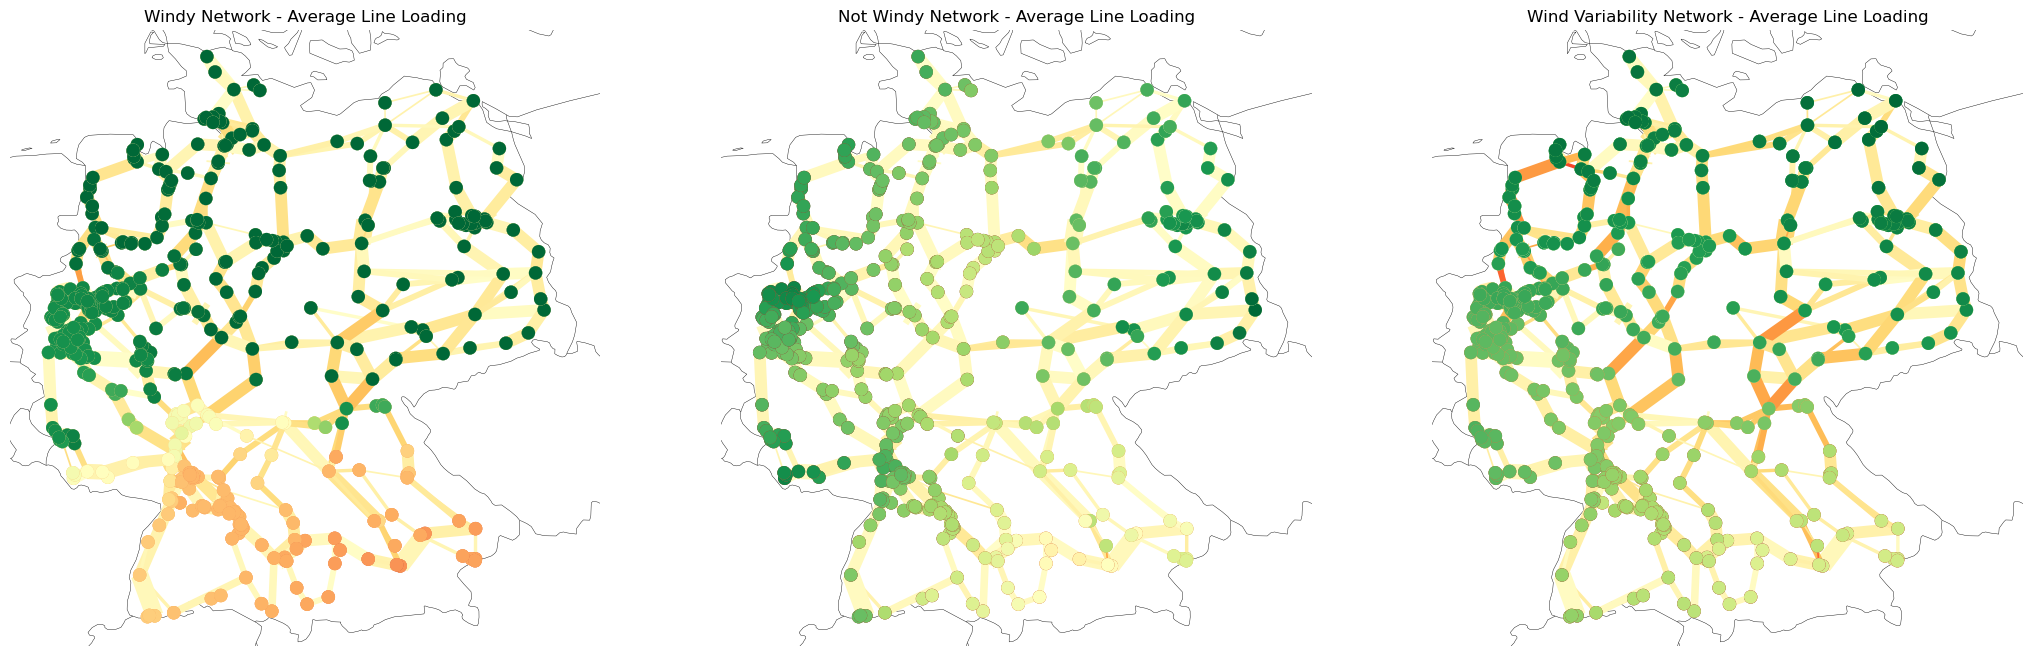

In [12]:
# --- Create enhanced visualization ---
fig, axes = plt.subplots(1, 3, figsize=(26, 8), subplot_kw={"projection": ccrs.EqualEarth()})

# --- Helper Function to Plot Network with Average Loading ---
def plot_network_congestion(n, ax, title):
    avg_loading_n = (n.lines_t.p0.abs() / n.lines.s_nom).mean()
    avg_loading_links = (n.links_t.p0.abs() / n.links.p_nom).mean()
    
    # Find the time with the highest overall marginal price
    peak_price_time = n.buses_t.marginal_price.max(axis=1).idxmax()
    peak_prices = n.buses_t.marginal_price.loc[peak_price_time]
    log_print(f"Plotting '{n.name}' network at time {peak_price_time} with peak marginal price {peak_prices.max():.2f} €/MWh")

    min_prices = n.buses_t.marginal_price.loc[peak_price_time]
    log_print(f"Minimum marginal price across all buses at peak time: {min_prices.min():.2f} €/MWh")
    
    n.plot(
        ax=ax,
        geomap=True,
        title=title,
        bus_sizes=0.01,
        bus_colors=peak_prices,
        bus_cmap='RdYlGn_r',
        line_colors=avg_loading_n,
        link_colors=avg_loading_links,
        line_cmap="YlOrRd",
        link_cmap="RdYlGn_r",
        line_width=n.lines.s_nom / 400,
        link_width=n.links.p_nom / 400,
    )

    return peak_prices

# Plot Average Loading Over All Snapshots for each network
i = 0
for n in networks.values():
    peak_prices = plot_network_congestion(n, axes[i], n.name + " Network - Average Line Loading")
    log_print(f"\n{n.name} Marginal Price Statistics:")
    log_print(peak_prices.describe().to_string())
    log_print("")
    i += 1

save_fig(fig, "02_marginal_prices.png")

### Load shedding

 Network: Windy
  Average loading across all lines: 27.16%
  Max average loading: 231.12%
  Lines with >60% avg loading: 34
  Lines with >70% avg loading: 19

 Network: Not Windy
  Average loading across all lines: 14.34%
  Max average loading: 229.26%
  Lines with >60% avg loading: 3
  Lines with >70% avg loading: 2

 Network: Wind Variability
  Average loading across all lines: 32.35%
  Max average loading: 196.65%
  Lines with >60% avg loading: 80
  Lines with >70% avg loading: 46

Saved figure: /home/lucakristin/Desktop/my_pypsa/pypsa-eur/analysis/germany_base-ext_/03_load_shedding.png


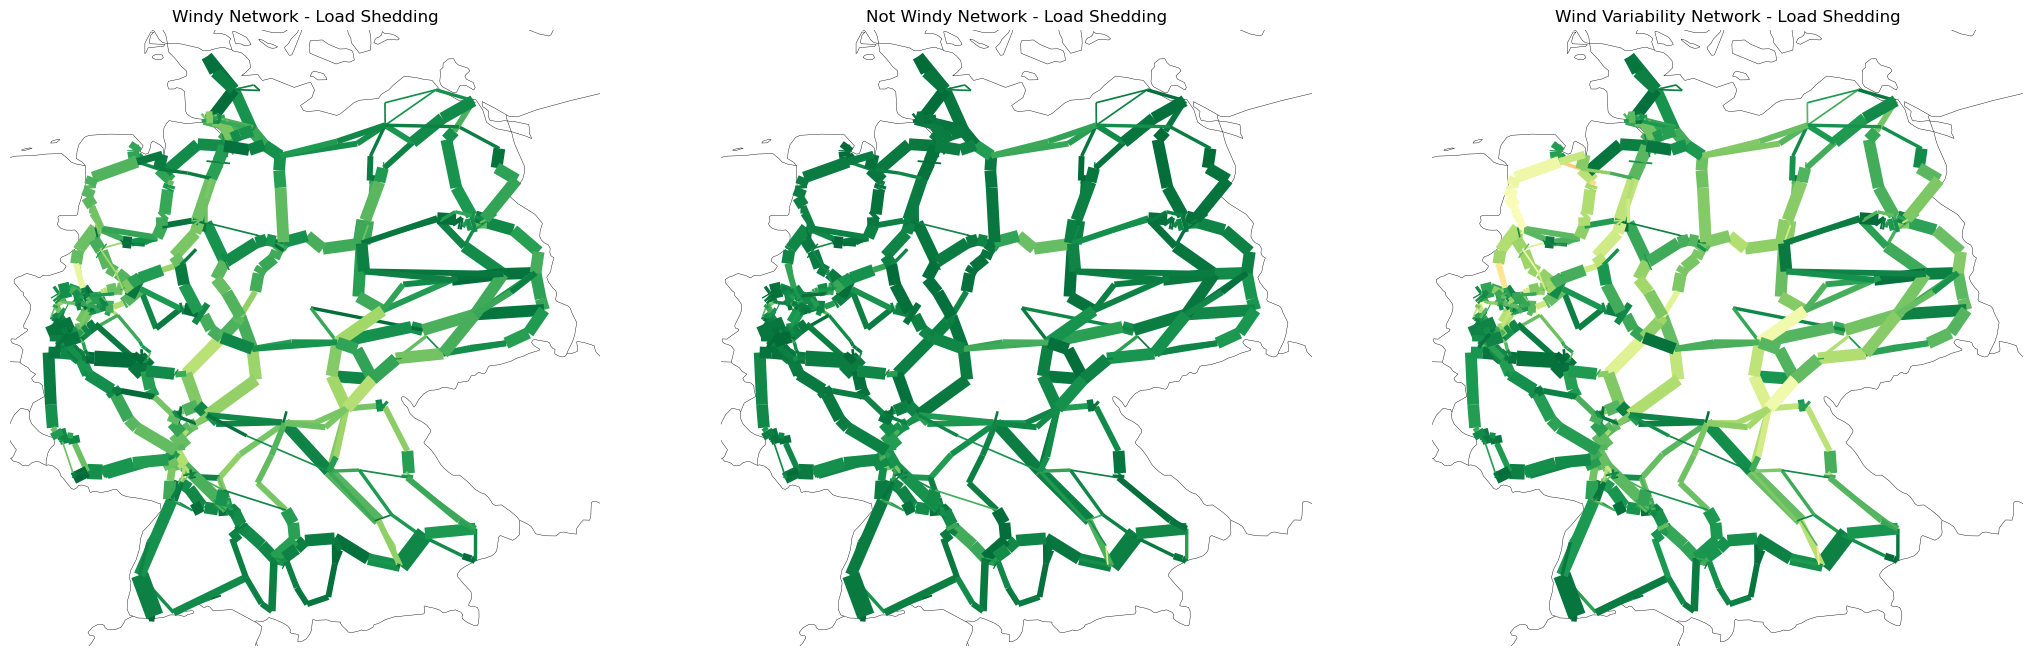

In [13]:
# --- Create enhanced visualization ---
fig, axes = plt.subplots(1, 3, figsize=(26, 8), subplot_kw={"projection": ccrs.EqualEarth()})

# --- Helper Function to Plot Network with Average Loading ---
def plot_network_load(n, ax, title):
    avg_loading_n = (n.lines_t.p0.abs() / n.lines.s_nom).mean()
    load_mask = n.generators.carrier.str.contains("load", case=False, na=False)
    shed_gens = n.generators.index[load_mask]

    if len(shed_gens) == 0:
        log_print("No generator carrier containing 'load' found. Plot will show zeros.")
        shed_by_bus_time = pd.DataFrame(
            0.0, index=n.snapshots, columns=n.buses.index
        )
    else:
        # Time series of unmet load aggregated by bus [MW].
        shed_by_bus_time = (
            n.generators_t.p[shed_gens]
            .T.groupby(n.generators.loc[shed_gens, "bus"])
            .sum()
            .T
            .reindex(columns=n.buses.index, fill_value=0.0)
        )

    # Pick the snapshot with the highest system-wide unmet load.
    total_shed = shed_by_bus_time.sum(axis=1)
    worst_shed_snapshot = total_shed.idxmax()
    unmet_load_at_snapshot = shed_by_bus_time.loc[worst_shed_snapshot]
    
    n.plot(
        ax=ax,
        geomap=True,
        title=title,
        bus_sizes=unmet_load_at_snapshot/5000,
        bus_alpha=0.5,
        bus_cmap="YlOrRd",
        line_colors=avg_loading_n,
        line_cmap="RdYlGn_r",
        line_width=n.lines.s_nom / 400,
        link_width=n.links.p_nom / 400 if not n.links.empty else 0,
    )

    return avg_loading_n

# Plot Average Loading Over All Snapshots for each network
i = 0
for n in networks.values():
    avg_loading = plot_network_load(n, axes[i], n.name + " Network - Load Shedding")
    log_print("=" * 70)
    log_print(f" Network: {n.name}")
    log_print(f"  Average loading across all lines: {avg_loading.mean():.2%}")
    log_print(f"  Max average loading: {avg_loading.max():.2%}")
    log_print(f"  Lines with >60% avg loading: {(avg_loading > 0.6).sum()}")
    log_print(f"  Lines with >70% avg loading: {(avg_loading > 0.7).sum()}")
    log_print("=" * 70)
    log_print("")
    i += 1

save_fig(fig, "03_load_shedding.png")

In [14]:
n.links.groupby("carrier").sum()

,bus0,bus1,type,efficiency,active,build_year,lifetime,p_nom,p_nom_mod,p_nom_extendable,...,min_up_time,min_down_time,up_time_before,down_time_before,ramp_limit_up,ramp_limit_down,ramp_limit_start_up,ramp_limit_shut_down,p_nom_opt,reversed
carrier,,,,,,,,,,,,,,,,,,,,,
H2 Electrolysis,DE0 0DE0 1DE0 10DE0 100DE0 101DE0 102DE0 103DE...,DE0 0 H2DE0 1 H2DE0 10 H2DE0 100 H2DE0 101 H2D...,,314.730000,450,0,11250.0,0.0,0.0,450,...,0,0,450,0,0.0,0.0,0.0,0.0,0.050840,0
H2 Fuel Cell,DE0 0 H2DE0 1 H2DE0 10 H2DE0 100 H2DE0 101 H2D...,DE0 0DE0 1DE0 10DE0 100DE0 101DE0 102DE0 103DE...,,225.000000,450,0,4500.0,0.0,0.0,450,...,0,0,450,0,0.0,0.0,0.0,0.0,0.022192,0
battery charger,DE0 0DE0 1DE0 10DE0 100DE0 101DE0 102DE0 103DE...,DE0 0 batteryDE0 1 batteryDE0 10 batteryDE0 10...,,440.908154,450,0,4500.0,0.0,0.0,450,...,0,0,450,0,0.0,0.0,0.0,0.0,1.822859,0
battery discharger,DE0 0 batteryDE0 1 batteryDE0 10 batteryDE0 10...,DE0 0DE0 1DE0 10DE0 100DE0 101DE0 102DE0 103DE...,,440.908154,450,0,4500.0,0.0,0.0,450,...,0,0,450,0,0.0,0.0,0.0,0.0,1.860447,0


Average link loading for Windy:
name
DE0 0 H2 Electrolysis        inf
DE0 1 H2 Electrolysis        inf
DE0 10 H2 Electrolysis       inf
DE0 100 H2 Electrolysis      inf
DE0 101 H2 Electrolysis      inf
                            ... 
DE0 95 battery discharger    inf
DE0 96 battery discharger    inf
DE0 97 battery discharger    inf
DE0 98 battery discharger    inf
DE0 99 battery discharger    inf
Length: 1800, dtype: float64
Average link loading for Not Windy:
name
DE0 0 H2 Electrolysis        inf
DE0 1 H2 Electrolysis        inf
DE0 10 H2 Electrolysis       inf
DE0 100 H2 Electrolysis      inf
DE0 101 H2 Electrolysis      inf
                            ... 
DE0 95 battery discharger    inf
DE0 96 battery discharger    inf
DE0 97 battery discharger    inf
DE0 98 battery discharger    inf
DE0 99 battery discharger    inf
Length: 1800, dtype: float64
Average link loading for Wind Variability:
name
DE0 0 H2 Electrolysis        inf
DE0 1 H2 Electrolysis        inf
DE0 10 H2 Electrolysis  

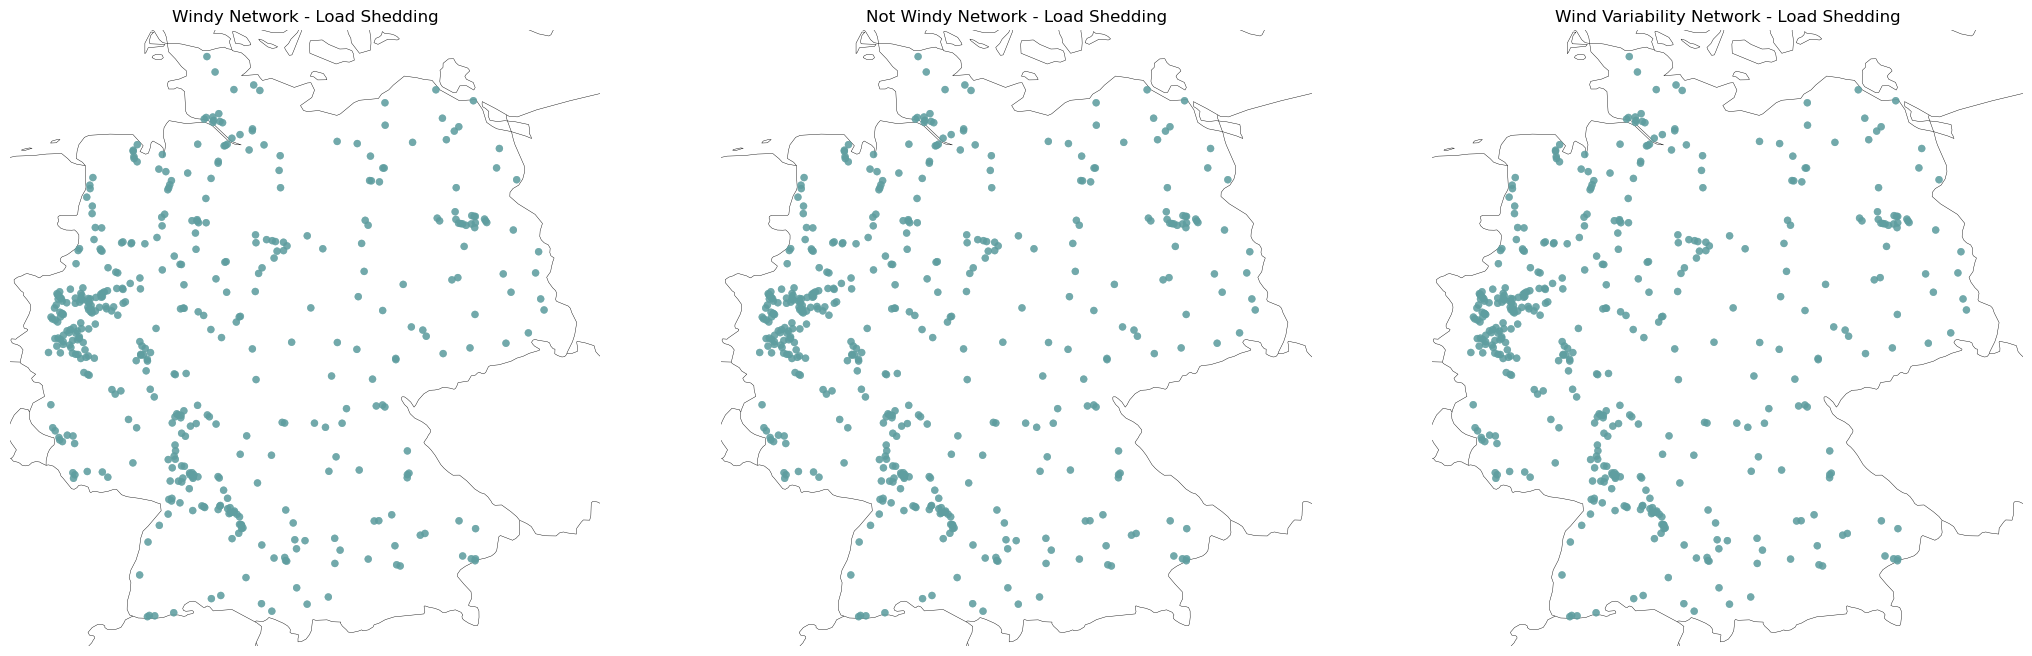

In [15]:
# --- Create enhanced visualization ---
fig, axes = plt.subplots(1, 3, figsize=(26, 8), subplot_kw={"projection": ccrs.EqualEarth()})

# --- Helper Function to Plot Network with Average Loading ---
def plot_network_load(n, ax, title):
    avg_loading_n = (n.lines_t.p0.abs() / n.lines.s_nom).mean()
    avg_loading_links = (n.links_t.p0.abs() / n.links.p_nom).mean()
    print(f"Average link loading for {n.name}:")
    print(avg_loading_links)
    
    n.plot(
        ax=ax,
        geomap=True,
        title=title,
        bus_sizes=0.003,
        bus_alpha=0.5,
        bus_cmap="YlOrRd",
        line_colors=avg_loading_n,
        link_colors=avg_loading_links,
        link_cmap="RdYlGn_r",
        line_width=0,
        link_width=n.links.p_nom / 400,
    )

    return avg_loading_n

# Plot Average Loading Over All Snapshots for each network
i = 0
for n in networks.values():
    avg_loading = plot_network_load(n, axes[i], n.name + " Network - Load Shedding")
    i += 1


##### Offshore Wind Curtailment


#### Parameter Documentation for New Curtailment Function

**Parameters Used:**

1. **`generators.p_nom`** (static, MW) — Installed/nameplate capacity
   - *Why:* Represents the fixed maximum power the generator can produce (unless extendable).
   - *Used when:* Generator capacity was not optimized.

2. **`generators.p_nom_opt`** (output, MW) — Optimized capacity after solving
   - *Why:* After optimization, if `p_nom_extendable=True`, this holds the actual capacity built. For post-solve analysis, we should use this.
   - *Fallback:* If `p_nom_opt` is NaN, we fall back to `p_nom`.
   - **This is the key fix:** The old function ignored optimization, always using `p_nom`.

3. **`generators_t.p_max_pu`** (time series, per unit, 0-1) — Maximum output availability factor
   - *Why:* For renewables, this is the capacity factor from weather (wind speed, solar irradiance). For conventional plants, it's the de-rating factor (maintenance, forced outages, etc.).
   - *Formula:* Available Power[t] = `p_max_pu[t]` × `p_nom_eff`

4. **`generators_t.p`** (time series, MW) — Actual dispatched power (solver output)
   - *Why:* This is what was actually generated. Curtailment = Available − Dispatched.

5. **`generators.carrier`** (string) — Energy carrier type (e.g., 'onwind', 'offwind-ac', 'solar')
   - *Why:* Allows filtering/grouping by technology type for separate analysis.

**The Curtailment Equation:**

$$\text{Curtailed Power}[t] = \max\left(0, \, p\_max\_pu[t] \times p\_nom\_eff \, - \, p[t] \right)$$

where $p\_nom\_eff = p\_nom\_opt$ if extendable (and not NaN), otherwise $p\_nom$.


In [16]:
def plot_curtailment(n, carrier, ax):
    p_available_by_carrier = (
        n.generators_t.p_max_pu.multiply(n.generators.p_nom).T.groupby(n.generators.carrier).sum().T
    )
    p_by_carrier = n.generators_t.p.T.groupby(n.generators.carrier).sum().T
    p_curtailed_by_carrier = p_available_by_carrier - p_by_carrier

    # Correct for any minor negative values from floating point inaccuracies.
    p_curtailed_by_carrier[p_curtailed_by_carrier < 0] = 0

    capacity = n.generators.groupby("carrier")["p_nom"].sum().at[carrier]

    p_df = pd.DataFrame(
        {
            carrier + " available": p_available_by_carrier[carrier],
            carrier + " dispatched": p_by_carrier[carrier],
            carrier + " curtailed": p_curtailed_by_carrier[carrier],
        }
    )

    p_df[carrier + " capacity"] = capacity
    p_df[[carrier + " dispatched", carrier + " curtailed"]].plot(kind="area", ax=ax, lw=0)
    p_df[[carrier + " available", carrier + " capacity"]].plot(ax=ax)

    

    p_available = n.generators_t.p_max_pu.multiply(n.generators.p_nom)
    p_av_by = p_available.T.groupby(n.generators.carrier).sum().T
    p_disp_by = n.generators_t.p.T.groupby(n.generators.carrier).sum().T
    p_cur = (p_av_by - p_disp_by).clip(lower=0)

    tot_av = p_av_by[carrier].sum()
    tot_disp = p_disp_by[carrier].sum()
    tot_cur = p_cur[carrier].sum()

    ax.set_xlabel("")
    ax.set_ylabel("Power [MW]")
    ax.set_ylim([0, p_df[carrier + " capacity"].max() * 1.1 if hasattr(p_df[carrier + " capacity"], "max") else None])
    ax.set_title(f"{n.name} - {carrier} Curtailment")
    
    log_print("=" * 70)
    log_print(f"Network: {n.name}")
    log_print(f"{carrier} capacity MW: {n.generators.groupby('carrier')['p_nom'].sum().get(carrier):.2f}")
    log_print(f"Total available (MWh): {tot_av:.2f}")
    log_print(f"Total dispatched (MWh): {tot_disp:.2f}")
    log_print(f"Total curtailed (MWh): {tot_cur:.2f}")
    log_print(f"Curtailed fraction: {tot_cur / tot_av if tot_av else float('nan'):.2f}")
    log_print("=" * 70)
    log_print("")



#### offwind

Network: Windy
offwind-ac capacity MW: 11163.74
Total available (MWh): 236217.48
Total dispatched (MWh): 65357.62
Total curtailed (MWh): 170859.86
Curtailed fraction: 0.72

Network: Not Windy
offwind-ac capacity MW: 11163.74
Total available (MWh): 8316.63
Total dispatched (MWh): 8316.63
Total curtailed (MWh): 0.00
Curtailed fraction: 0.00

Network: Wind Variability
offwind-ac capacity MW: 11163.74
Total available (MWh): 173568.76
Total dispatched (MWh): 159684.94
Total curtailed (MWh): 13883.82
Curtailed fraction: 0.08

Saved figure: /home/lucakristin/Desktop/my_pypsa/pypsa-eur/analysis/germany_base-ext_/04_offwind_curtailment.png


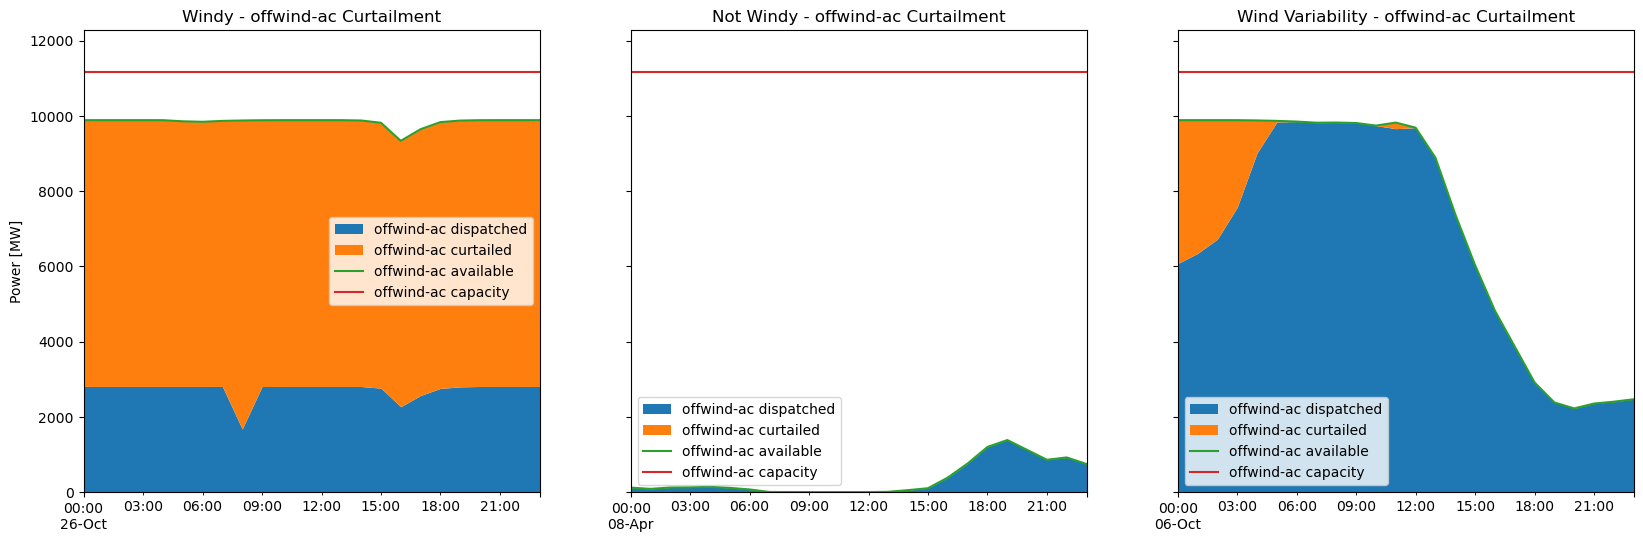

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

plot_curtailment(n1, "offwind-ac", axes[0])
plot_curtailment(n2, "offwind-ac", axes[1])
plot_curtailment(n3, "offwind-ac", axes[2])

save_fig(fig, "04_offwind_curtailment.png")

#### onwind

Network: Windy
onwind capacity MW: 73332.07
Total available (MWh): 1520776.20
Total dispatched (MWh): 1007247.99
Total curtailed (MWh): 513528.21
Curtailed fraction: 0.34

Network: Not Windy
onwind capacity MW: 73332.07
Total available (MWh): 49435.40
Total dispatched (MWh): 49435.08
Total curtailed (MWh): 0.32
Curtailed fraction: 0.00

Network: Wind Variability
onwind capacity MW: 73332.07
Total available (MWh): 804830.80
Total dispatched (MWh): 772572.37
Total curtailed (MWh): 32258.43
Curtailed fraction: 0.04

Saved figure: /home/lucakristin/Desktop/my_pypsa/pypsa-eur/analysis/germany_base-ext_/05_onwind_curtailment.png


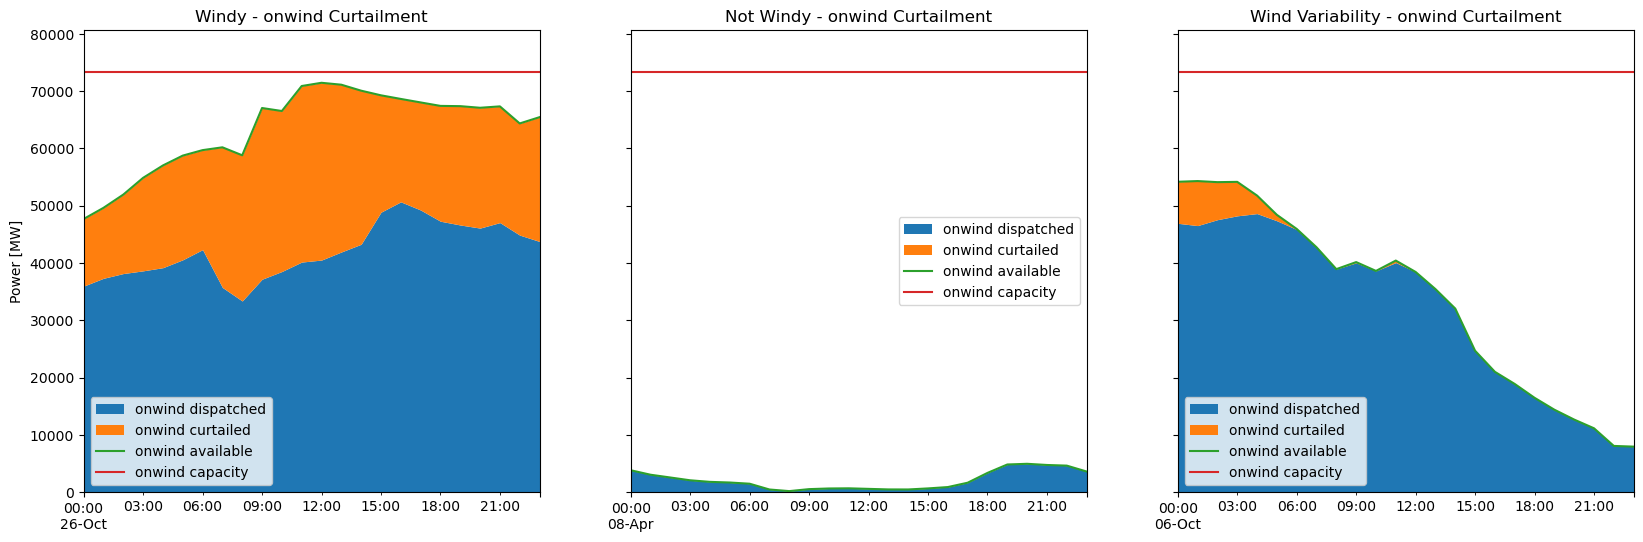

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

plot_curtailment(n1, "onwind", axes[0])
plot_curtailment(n2, "onwind", axes[1])
plot_curtailment(n3, "onwind", axes[2])

save_fig(fig, "05_onwind_curtailment.png")

#### solar

Network: Windy
solar capacity MW: 86408.00
Total available (MWh): 121780.28
Total dispatched (MWh): 121070.99
Total curtailed (MWh): 709.29
Curtailed fraction: 0.01

Network: Not Windy
solar capacity MW: 86408.00
Total available (MWh): 438181.16
Total dispatched (MWh): 438180.65
Total curtailed (MWh): 0.51
Curtailed fraction: 0.00

Network: Wind Variability
solar capacity MW: 86408.00
Total available (MWh): 90121.28
Total dispatched (MWh): 90117.39
Total curtailed (MWh): 3.88
Curtailed fraction: 0.00

Saved figure: /home/lucakristin/Desktop/my_pypsa/pypsa-eur/analysis/germany_base-ext_/05_solar_curtailment.png


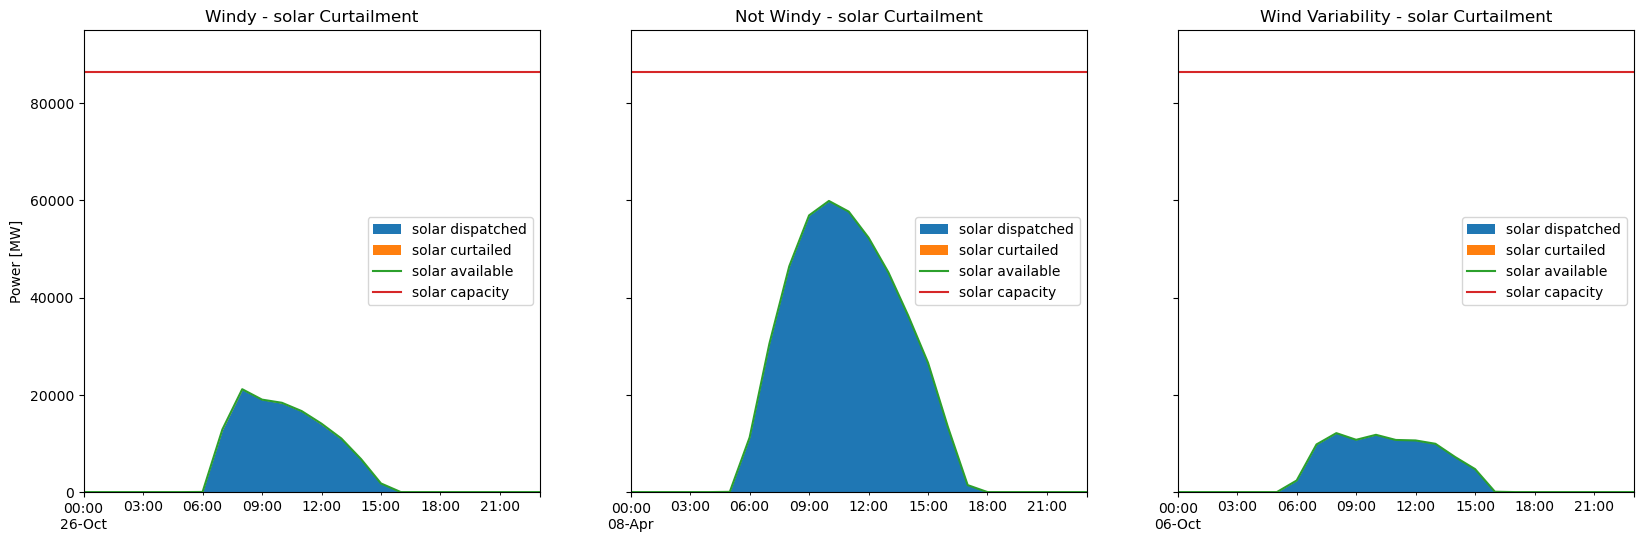

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

plot_curtailment(n1, "solar", axes[0])
plot_curtailment(n2, "solar", axes[1])
plot_curtailment(n3, "solar", axes[2])

save_fig(fig, "05_solar_curtailment.png")

### 4.2 Generation and Capacity Comparison

##### Power Dispatch by Carrier

Saved figure: /home/lucakristin/Desktop/my_pypsa/pypsa-eur/analysis/germany_base-ext_/06_power_dispatch.png


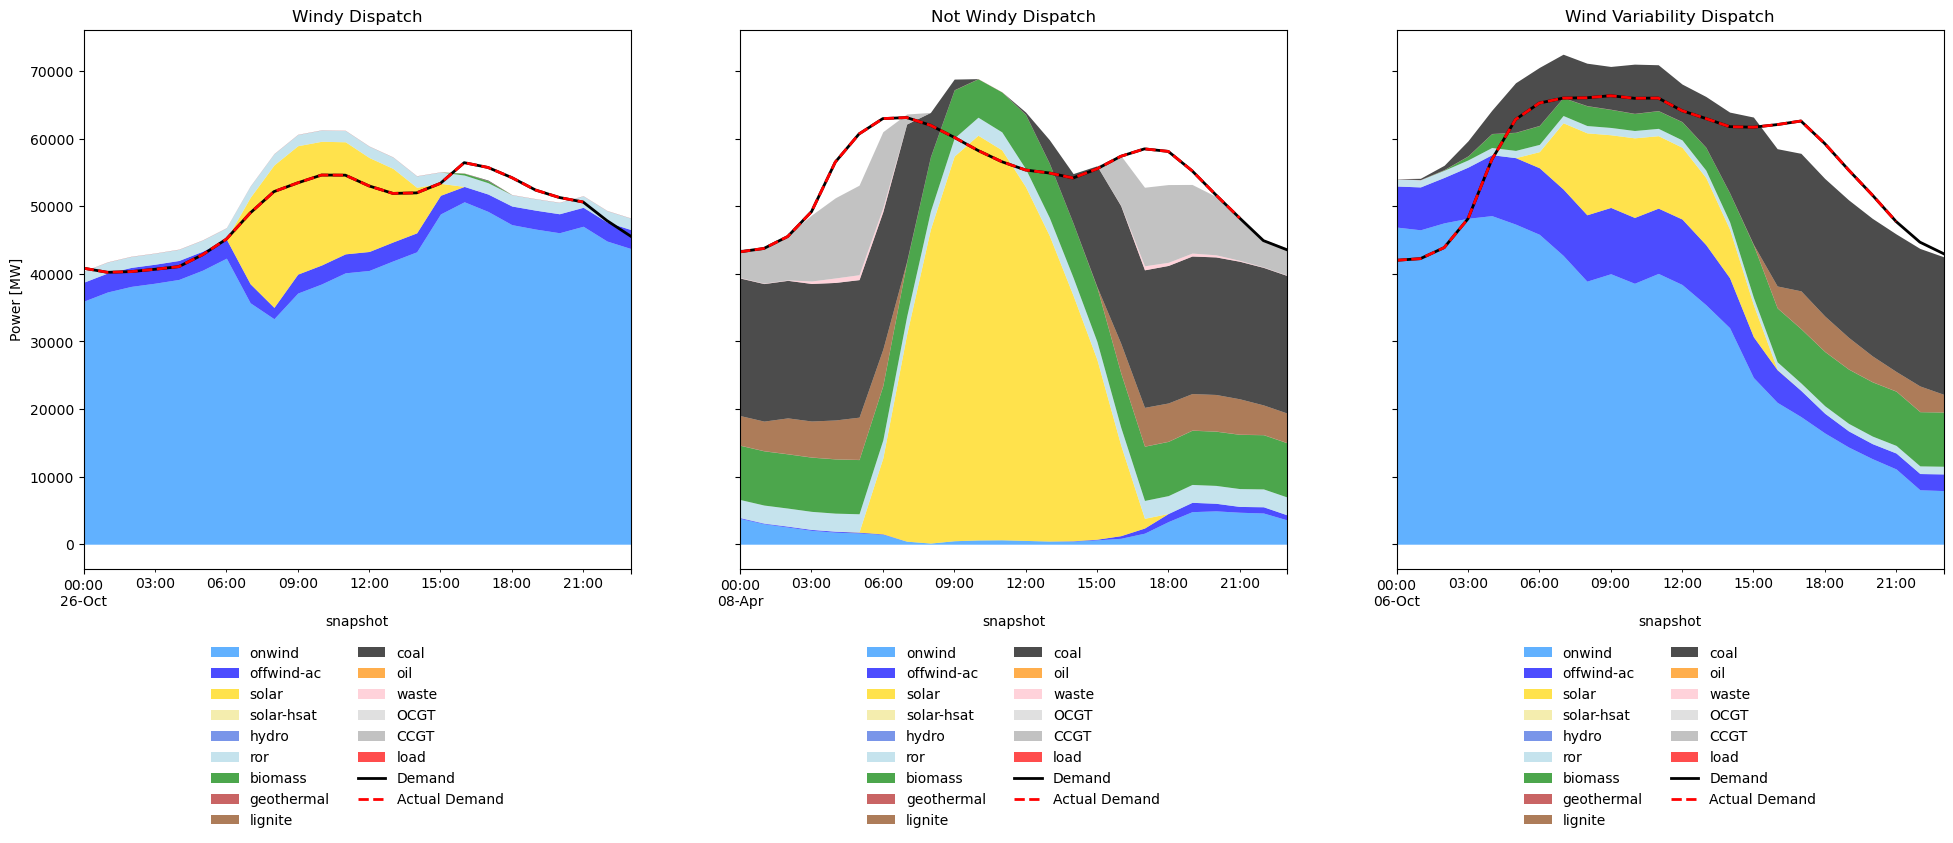

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(24, 7), sharey=True)

# --- Define Colors and Order ---
colors = {
    # Wind
    "onwind": "dodgerblue",
    "offwind-ac": "blue",
    "offwind-float": "steelblue",
    # Solar
    "solar": "gold",
    "solar-hsat": "khaki",
    # Hydro
    "hydro": "royalblue",
    "ror": "lightblue",
    # Fossil Fuels
    "lignite": "saddlebrown",
    "coal": "black",
    "oil": "darkorange",
    "OCGT": "lightgray",
    "CCGT": "darkgray",
    # Other
    "biomass": "green",
    "waste": "pink",
    "geothermal": "firebrick",
    "load": "red"
}

cols = [
    # Renewables
    "onwind", "offwind-ac", 
    "solar", "solar-hsat",
    "hydro", "ror",
    "biomass", "geothermal",
    # Conventional
    "lignite", "coal", "oil", "waste",
    "OCGT", "CCGT",
    # Storage
    "load"
]

# --- Helper function for plotting ---
def plot_dispatch(n, ax, title):
    p_by_carrier = n.generators_t.p.T.groupby(n.generators.carrier).sum().T

    # Add battery discharge as another stacked supply source on the electricity side
    battery_discharge_dispatch = pd.Series(0.0, index=n.snapshots)
    if not n.links.empty and "battery discharger" in set(n.links.carrier):
        battery_discharge_dispatch = -n.links_t.p1.loc[:, n.links.carrier == "battery discharger"].sum(axis=1)

    p_by_carrier["battery discharge"] = battery_discharge_dispatch

    # Reorder and fill missing columns
    p_by_carrier = p_by_carrier.reindex(columns=cols).fillna(0)

    # Get colors in the correct order
    c = [colors.get(col, "gray") for col in p_by_carrier.columns]

    p_by_carrier.plot(kind="area", ax=ax, lw=0, title=title, color=c, alpha=0.7)

    # Add demand curve
    demand = n.loads_t.p_set.sum(axis=1)
    demand.plot(ax=ax, color="black", lw=2, label="Demand")

    scenario_title = n.name

    real_data = pd.read_csv(f"/home/lucakristin/Desktop/my_pypsa/actual_electricity_data/combined_{scenario_title.replace(' ', '_').lower()}.csv", index_col=0, parse_dates=True)
    demand_real = real_data["grid load"]
    # Use simulation snapshots as index for real data to align with simulation time axis
    demand_real = pd.Series(demand_real.values, index=n.snapshots, name="Actual Demand")
    # Shift real data by two hours
    demand_real = demand_real.shift(-2)
    demand_real.plot(ax=ax, color="red",  linestyle="--", lw=2, label="Actual Demand")

    ax.set_ylabel("Power [MW]")
    ax.legend(ncol=2, loc="upper center", bbox_to_anchor=(0.5, -0.12), frameon=False)

# --- Plotting ---
plot_dispatch(n1, axes[0], "Windy Dispatch")
plot_dispatch(n2, axes[1], "Not Windy Dispatch")
plot_dispatch(n3, axes[2], "Wind Variability Dispatch")

save_fig(fig, "06_power_dispatch.png")

##### Total Energy Production by Carrier

Saved figure: /home/lucakristin/Desktop/my_pypsa/pypsa-eur/analysis/germany_base-ext_/07_energy_production.png

=== Energy Production Summary ===
                   Windy      Not Windy  Wind Variability
carrier                                                  
onwind      1.007248e+06   49435.081220     772572.367117
solar       1.210710e+05  438180.652739      90117.394135
coal        9.253078e+01  362760.507477     262073.729008
biomass     5.518776e+02  187126.238144     103662.728394
offwind-ac  6.535762e+04    8316.625420     159684.939987
ror         3.999489e+04   63871.473312      26203.864314
CCGT        3.411121e-03  127570.819797          0.205263
lignite     6.065436e-04   77485.266679      31896.350238
waste       2.573024e-03    4639.046925          0.224916
geothermal  6.455548e+02     645.591310        645.596236
OCGT        4.344097e-03       1.734158          0.217998
oil         1.896161e-03       0.354445          0.075196




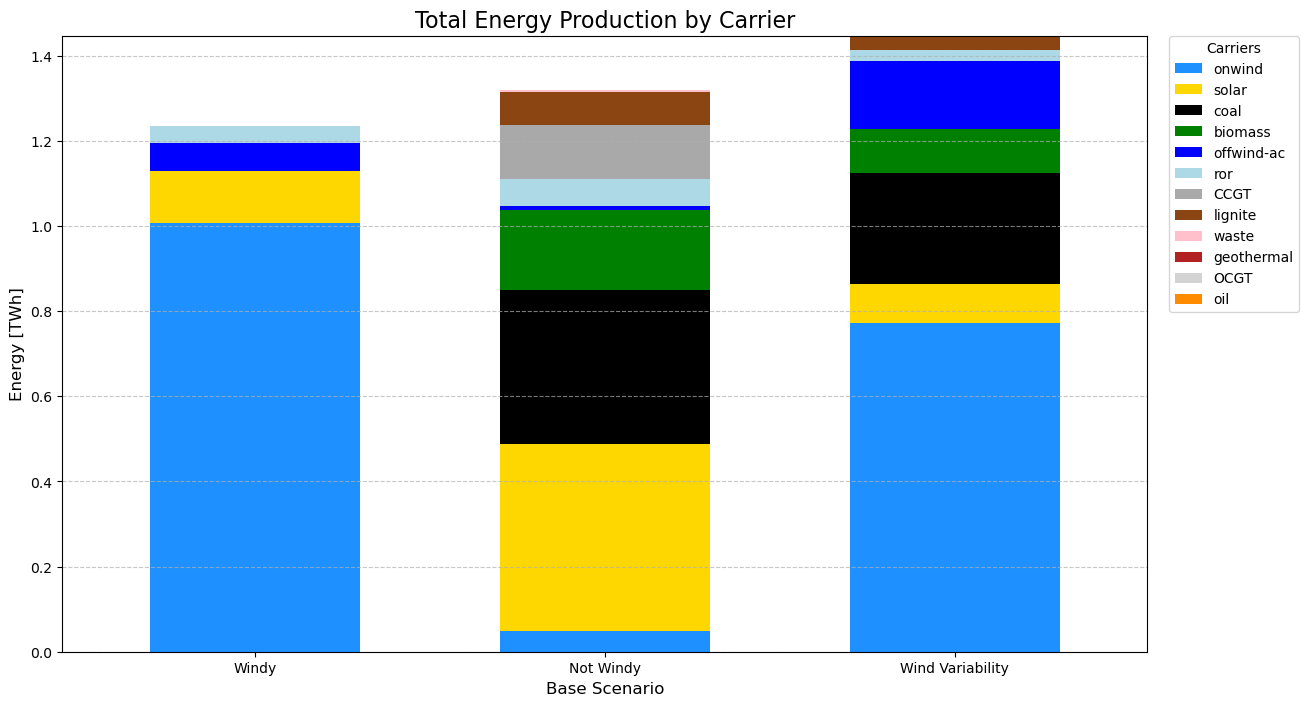

In [21]:
# --- Calculate energy production for each scenario ---
p_by_carrier_n1 = n1.generators_t.p.sum().groupby(n1.generators.carrier).sum()
p_by_carrier_n2 = n2.generators_t.p.sum().groupby(n2.generators.carrier).sum()
p_by_carrier_n3 = n3.generators_t.p.sum().groupby(n3.generators.carrier).sum()

# --- Create a DataFrame for plotting ---
energy_df = pd.DataFrame({
    "Windy": p_by_carrier_n1,
    "Not Windy": p_by_carrier_n2,
    "Wind Variability": p_by_carrier_n3
}).fillna(0)

# Filter out carriers with negligible energy
energy_df = energy_df[energy_df.sum(axis=1) > 0.1]

# --- Sort carriers by total energy production (descending) ---
energy_df = energy_df.loc[energy_df.sum(axis=1).sort_values(ascending=False).index]

# Get colors for the carriers that are present
bar_colors = [colors.get(carrier, "grey") for carrier in energy_df.index]

# --- Plotting ---
fig, ax = plt.subplots(figsize=(14, 8))

# Plot stacked bar chart
(energy_df.T / 1e6).plot(kind="bar", stacked=True, ax=ax, color=bar_colors, width=0.6)

# --- Formatting ---
ax.set_title("Total Energy Production by Carrier", fontsize=16)
ax.set_ylabel("Energy [TWh]", fontsize=12)
ax.set_xlabel("Base Scenario", fontsize=12)
ax.tick_params(axis='x', rotation=0)
ax.grid(axis='y', linestyle='--', alpha=0.7)

# --- Legend ---
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles, 
    labels, 
    title="Carriers",
    bbox_to_anchor=(1.02, 1), 
    loc='upper left', 
    borderaxespad=0.
)

save_fig(fig, "07_energy_production.png")

# Log energy production summary
log_print("\n=== Energy Production Summary ===")
log_print(energy_df.to_string())
log_print("\n")

In [22]:
def calculate_emissions(n):
    emission_factors = n.c.carriers.static.co2_emissions
    emitting_generators = n.c.generators.static[
        n.c.generators.static.carrier.map(emission_factors).fillna(0) != 0
    ]
    generator_p = n.c.generators.dynamic.p.loc[:, emitting_generators.index]
    generator_efficiency = n.c.generators._as_dynamic("efficiency").loc[:, emitting_generators.index]
    snapshot_weightings = n.snapshot_weightings.generators.reindex(generator_p.index)
    emission_factors_per_generator = emitting_generators.carrier.map(emission_factors)
    co2_emissions = (
        generator_p.multiply(snapshot_weightings, axis=0)
        .multiply(emission_factors_per_generator, axis=1)
        .divide(generator_efficiency)
        .sum()
        .sum()
    )
    return co2_emissions

log_print("\n=== CO2 Emissions Summary ===")
for n in networks.values():
    log_print(f"Total CO2 emissions at the {n.name} day: {calculate_emissions(n):.2f} kg CO2")
log_print("\n")


=== CO2 Emissions Summary ===
Total CO2 emissions at the Windy day: 146.66 kg CO2
Total CO2 emissions at the Not Windy day: 438356.16 kg CO2
Total CO2 emissions at the Wind Variability day: 255228.20 kg CO2




### Statistics

In [23]:
log_print("\n=== Network Statistics ===")
for n in networks.values():
    log_print(f"\nNetwork: {n.name}")
    log_print(n.statistics().to_string())
    log_print("\n")

log_print("\n=== Analysis Complete ===")
log_print(f"All results saved to: {analysis_dir}")


=== Network Statistics ===

Network: Windy
                                  Optimal Capacity  Installed Capacity        Supply    Withdrawal  Energy Balance  Transmission  Capacity Factor   Curtailment  Capital Expenditure  Operational Expenditure       Revenue  Market Value
Generator   Combined-Cycle Gas        3.078313e+04        3.078313e+04  3.410000e-03  0.000000e+00    3.410000e-03       0.00000     4.547946e-09  7.387951e+05         1.066291e+07                  0.15964  3.940000e-03      1.142857
            Offshore Wind (AC)        1.116374e+04        1.116374e+04  6.535762e+04  0.000000e+00    6.535762e+04       0.00000     2.439356e-01  1.708599e+05         9.110722e+06               1571.43889  1.608788e+03      0.024615
            Onshore Wind              7.333207e+04        7.333207e+04  1.007248e+06  0.000000e+00    1.007248e+06       0.00000     5.723099e-01  5.135282e+05         2.387208e+07              24952.14206  3.530029e+05      0.350463
            Open-Cyc